### [Temporal Fusion Transformers](https://levelup.gitconnected.com/temporal-fusion-transformers-d38ba3310ab9)

> A Deep Learning Strategy Applied to Financial Asset

In [1]:
# Silence TensorFlow backend logs (0=all, 1=info, 2=warning, 3=error only)
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [2]:
# Install TensorFlow (official website: <https://www.tensorflow.org/>)
!pip install -q tensorflow

In [3]:
# Install Yahoo Finance data downloader (<https://pypi.org/project/yfinance/>)
!pip install -q yfinance

In [4]:
# Install Technical Analysis indicators library (<https://pypi.org/project/ta/>)
!pip install -q ta
!pip install -q TA-Lib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 25.3 MB/s eta 0:00:00


In [5]:
# Imports
import os
import sys
from IPython.display import display

IN_COLAB = "google.colab" in sys.modules

import ta
import sklearn
import pandas as pd
import numpy as np
import tensorflow as tf
import yfinance as yf
import matplotlib.pyplot as plt

from tensorflow import keras
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")

In [6]:
# Function to download historical market data (2000–2025 full years)
def get_market_data(ticker, is_raw: bool = False):

  # Download data from 2000-01-01 to 2025-12-31
  df = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)

  if is_raw:
    return df

  keep = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
  df = df[[c for c in keep if c in df.columns]]

  # Standardize column names
  rename_map = {
      "Open": "open",
      "High": "high",
      "Low": "low",
      "Close": "close",
      "Adj Close": "adj_close",
      "Volume": "volume"
  }

  df = df.rename(columns=rename_map)
  # Name the index
  df.index.name = "date"
  return df

In [7]:
# Download LVMH data
df = get_market_data("MC.PA")

# Force flatten MultiIndex on df if still present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Download CAC 40
cac40_raw = get_market_data("^FCHI", is_raw=True)

# Force flatten MultiIndex on cac40
if isinstance(cac40_raw.columns, pd.MultiIndex):
    cac40_raw.columns = cac40_raw.columns.get_level_values(0)
cac40_raw.index.name = "date"
cac40_raw.columns = cac40_raw.columns.str.lower().str.replace(" ", "_")

# Create return series
cac40 = pd.DataFrame(index=cac40_raw.index)
cac40["cac40_return"] = cac40_raw["close"].pct_change()

# Both indexes must be DatetimeIndex with same freq - reset name to match
df.index.name = "date"
cac40.index.name = "date"

# Merge
df = df.join(cac40, how="left")

In [8]:
# Shape
df.shape

(6680, 6)

In [9]:
# Quick overview of summary
display(df.describe())

,open,high,low,close,volume,cac40_return
count,6680.000000,6680.000000,6680.000000,6680.000000,6.680000e+03,6643.000000
mean,208.624996,210.819992,206.293052,208.669315,9.955965e+05,0.000143
std,227.421393,229.774495,224.982584,227.401615,7.098424e+05,0.013724
min,10.311534,10.311534,10.311534,17.844971,0.000000e+00,-0.122768
25%,49.126143,49.845181,48.464819,49.183619,5.070905e+05,-0.006253
50%,101.275152,102.364190,100.271626,101.582264,8.197425e+05,0.000440
75%,311.220912,314.404833,306.602863,310.322647,1.272234e+06,0.006952
max,850.551867,858.539185,841.214911,851.027222,7.183691e+06,0.111762


In [10]:
# Quick overview of head records
display(df.head())

,open,high,low,close,volume,cac40_return
date,,,,,,
2000-01-03,56.738161,57.603638,54.525013,54.895935,615855,NaN
2000-01-04,56.132313,56.132313,49.703060,49.703060,1691700,-0.041463
2000-01-05,48.837600,49.332160,46.983008,48.021580,1563735,-0.033907
2000-01-06,47.972117,47.972117,46.030978,47.477562,1641215,-0.005400
2000-01-07,47.230282,47.477562,45.758969,47.477562,1360530,0.016422


In [11]:
# Quick overview of tail records
display(df.tail())

,open,high,low,close,volume,cac40_return
date,,,,,,
2025-12-22,631.000000,634.700012,625.799988,627.700012,242753,-0.003718
2025-12-23,627.700012,630.500000,625.200012,627.299988,161944,-0.002120
2025-12-24,629.700012,634.700012,629.500000,632.099976,55878,-0.000033
2025-12-29,632.900024,635.599976,629.099976,633.200012,199081,0.001042
2025-12-30,631.099976,641.599976,630.099976,639.299988,179559,0.006919


In [12]:
# Quick overview of random sample records
display(df.sample(20))

,open,high,low,close,volume,cac40_return
date,,,,,,
2011-09-14,82.571367,85.464603,81.924197,84.893570,1402034,0.018726
2024-07-03,690.805224,702.028366,689.257225,691.579224,323582,0.012442
2001-02-08,43.007302,43.007302,41.636057,42.197018,628239,0.003706
2009-01-13,32.340075,32.842808,31.506975,32.842808,1410823,-0.014858
2024-09-03,655.490917,659.360974,648.234560,649.105347,250244,-0.009327
2024-10-03,643.784064,643.880792,632.947892,639.526978,338628,-0.013172
2025-06-09,466.969337,473.265002,466.424056,467.514618,390447,-0.001717
2011-08-05,84.512880,90.984588,83.408886,87.710663,2378103,-0.012586
2020-08-06,342.919542,344.836291,337.488679,341.367859,360618,-0.009772


In [13]:
def feature_engineering(df):
    df = df.copy()

    # Target variable
    df["return"] = df["close"].pct_change()

    # Lagged prices
    df["lag_open"]   = df["open"].shift(1)
    df["lag_high"]   = df["high"].shift(1)
    df["lag_low"]    = df["low"].shift(1)
    df["lag_close"]  = df["close"].shift(1)
    df["lag_volume"] = df["volume"].shift(1)

    # Moving averages
    df["sma_15"] = df["close"].rolling(15).mean().shift(1)
    df["sma_60"] = df["close"].rolling(60).mean().shift(1)

    # Volatility
    df["volatility_15"] = df["return"].rolling(15).std().shift(1)
    df["volatility_60"] = df["return"].rolling(60).std().shift(1)

    # VWAP
    vwap = ta.volume.VolumeWeightedAveragePrice(
        high=df["high"], low=df["low"],
        close=df["close"], volume=df["volume"], window=5
    )
    df["vwap"] = vwap.vwap.shift(1)

    # RSI
    rsi = ta.momentum.RSIIndicator(df["close"], window=5)
    df["rsi"] = rsi.rsi().shift(1)

    # MACD
    macd = ta.trend.MACD(df["close"])
    df["macd"]        = macd.macd().shift(1)
    df["macd_signal"] = macd.macd_signal().shift(1)
    df["macd_diff"]   = macd.macd_diff().shift(1)

    # Bollinger Bands
    bb = ta.volatility.BollingerBands(df["close"], window=20)
    df["bb_upper"] = bb.bollinger_hband().shift(1)
    df["bb_lower"] = bb.bollinger_lband().shift(1)
    df["bb_width"] = (df["bb_upper"] - df["bb_lower"]).shift(1)

    # ATR
    atr = ta.volatility.AverageTrueRange(
        high=df["high"], low=df["low"], close=df["close"], window=14
    )
    df["atr"] = atr.average_true_range().shift(1)

    # OBV
    obv = ta.volume.OnBalanceVolumeIndicator(
        close=df["close"], volume=df["volume"]
    )
    df["obv"] = obv.on_balance_volume().shift(1)

    # CAC 40 lagged return
    df["cac40_return_lag"] = df["cac40_return"].shift(1)

    # Calendar features
    df["day_of_week"] = df.index.dayofweek
    df["month"]       = df.index.month
    df["quarter"]     = df.index.quarter

    return df.dropna()

In [14]:
df = feature_engineering(df)
display(df.sample(20))

,open,high,low,close,volume,cac40_return,return,lag_open,lag_high,lag_low,...,macd_diff,bb_upper,bb_lower,bb_width,atr,obv,cac40_return_lag,day_of_week,month,quarter
date,,,,,,,,,,,,,,,,,,,,,
2011-11-25,81.315114,82.799798,79.982703,82.304901,734853,0.012302,0.011226,81.657724,83.370823,80.858275,...,-0.956391,93.355854,80.771136,13.161702,2.690525,45512726.0,-0.000064,4,11,4
2008-06-19,50.221872,50.576046,49.818114,49.839363,1336593,-0.005924,-0.016907,51.263149,51.631488,50.243126,...,-0.214531,53.574958,49.794273,3.682861,1.109480,52031058.0,-0.014421,3,6,2
2004-10-25,34.865444,34.931352,34.469994,34.601810,1330932,-0.021184,-0.021435,35.854053,35.952913,35.194971,...,-0.154860,37.648109,35.094775,2.442441,0.728025,-2315316.0,-0.000098,0,10,4
2024-10-01,657.909733,663.811547,638.946476,642.429504,602354,-0.008078,-0.035585,676.679536,684.806620,665.262819,...,11.363895,667.248783,542.666573,119.324461,18.051081,139785163.0,-0.020026,1,10,4
2018-08-08,268.592358,269.521453,264.831799,264.920288,427234,-0.003515,-0.012858,264.566335,269.432940,264.566335,...,0.000084,271.747577,254.319159,16.974233,5.199234,110239393.0,0.008057,2,8,3
2007-11-14,56.931932,57.951796,56.730734,57.459209,1714250,0.013485,0.016196,55.835761,56.744617,55.558246,...,-0.622400,63.059089,56.376570,6.014987,1.200700,71795012.0,0.000605,2,11,4
2015-03-10,137.221871,138.330478,136.318550,136.523849,803530,-0.011191,-0.009237,138.001960,138.412558,136.893341,...,-0.004741,138.795528,126.615011,13.598725,2.212075,84716907.0,-0.005469,1,3,1
2009-08-18,46.886966,47.033603,45.772530,46.674343,783768,0.009065,0.006800,47.986751,48.287358,46.271108,...,-0.056442,47.924890,43.980913,4.615796,1.563475,25413140.0,-0.021624,1,8,3
2005-01-11,36.966172,36.999355,36.402055,36.501606,1297237,-0.007435,-0.012567,37.297992,37.297992,36.733875,...,-0.015555,38.085120,35.551876,2.633495,0.583040,9804747.0,-0.000036,1,1,1


In [15]:
# Train/validation/test split (time series)
split_train = int(0.85 * len(df))
split_valid = int(0.95 * len(df))

In [16]:
# Feature columns — now includes all optimized indicators
features = [
    "vwap",
    "rsi",
    "sma_15",
    "sma_60",
    "volatility_15",
    "volatility_60",
    "lag_open",
    "lag_high",
    "lag_low",
    "lag_close",
    "lag_volume",
    "macd",
    "macd_signal",
    "macd_diff",
    "bb_upper",
    "bb_lower",
    "bb_width",
    "atr",
    "obv",
    "cac40_return_lag",
    "day_of_week",
    "month",
    "quarter"
]

target = ["return"]

# Train dataset
X_train = df[features].iloc[:split_train]
y_train = df[target].iloc[:split_train]

# Validation dataset
X_valid = df[features].iloc[split_train:split_valid]
y_valid = df[target].iloc[split_train:split_valid]

# Test dataset
X_test = df[features].iloc[split_valid:]
y_test = df[target].iloc[split_valid:]

In [17]:
# Scaler for features
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_valid_sc = scaler_X.transform(X_valid)
X_test_sc  = scaler_X.transform(X_test)

# Scaler for target — equally important
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_valid_sc = scaler_y.transform(y_valid)
y_test_sc  = scaler_y.transform(y_test)

In [18]:
# Function to reshape data for time series sequences
def reshape_sequences(X_s, y_s, lag):
  if len(X_s) != len(y_s):
      print("Warning: X and y have different lengths")

  # Build X as (samples, lag, features)
  X = []
  for i in range(lag, X_s.shape[0]):
      X.append(X_s[i - lag:i, :])

  X = np.array(X)

  # Build y as (samples, 1)
  y = y_s[lag:]
  y = y.reshape(-1, 1)

  return X, y

In [19]:
# Lag value
lag = 15

# Apply function to training data
X_train_final, y_train_final = reshape_sequences(
    X_train_sc, y_train_sc, lag
)

# Apply function to validation data
X_valid_final, y_valid_final = reshape_sequences(
    X_valid_sc, y_valid_sc, lag
)

# Apply function to test data
X_test_final, y_test_final = reshape_sequences(
    X_test_sc, y_test_sc, lag
)

In [20]:
# Positional encoding layer for time series
class PositionalEncoding(layers.Layer):
  def __init__(self, maxlen, embed_dim, **kwargs):
      super().__init__(**kwargs)
      self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

  def call(self, x):
      maxlen = tf.shape(x)[1]
      positions = tf.range(start=0, limit=maxlen, delta=1)
      positions = self.pos_emb(positions)
      return x + positions

In [21]:
# Transformer encoder block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
  # Layer normalization
  x = layers.LayerNormalization(epsilon=1e-6)(inputs)

  # Multi-head self-attention
  x = layers.MultiHeadAttention(
      key_dim=head_size,
      num_heads=num_heads,
      dropout=dropout
  )(x, x, x)

  # Dropout after attention
  x = layers.Dropout(dropout)(x)

  # Residual connection
  res = x + inputs

  # Layer normalization
  x = layers.LayerNormalization(epsilon=1e-6)(res)

  # Feed-forward network (Conv1D as Gated Residual Network)
  x = layers.Conv1D(
      filters=ff_dim,
      kernel_size=1,
      activation="relu"
  )(x)

  x = layers.Dropout(dropout)(x)

  x = layers.Conv1D(
      filters=inputs.shape[-1],
      kernel_size=1
  )(x)

  # Final residual connection
  return x + res

In [22]:
# Model builder function
def build_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0
):
  # Model input
  inputs = keras.Input(shape=input_shape)

  # Initialize input tensor
  x = inputs

  # Positional encoding — gives the Transformer a sense of temporal order
  x = PositionalEncoding(maxlen=input_shape[0], embed_dim=input_shape[1])(x)

  # LSTM layer (prepares the sequence for the attention mechanism)
  x = layers.LSTM(64, return_sequences=True)(x)

  # Transformer encoder blocks
  for _ in range(num_transformer_blocks):
      x = transformer_encoder(
          x,
          head_size=head_size,
          num_heads=num_heads,
          ff_dim=ff_dim,
          dropout=dropout
      )

  # GRU layer (gated unit that selects what information passes to the output)
  x = layers.GRU(100, return_sequences=False)(x)

  # Dropout
  x = layers.Dropout(mlp_dropout)(x)

  # Dense layer
  x = layers.Dense(mlp_units, activation="relu")(x)

  # Output layer
  outputs = layers.Dense(1)(x)

  return keras.Model(inputs, outputs)

In [23]:
# Model builder function
def build_lstm_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0
):

    # Model input
    inputs = keras.Input(shape=input_shape)

    # Initialize input tensor
    x = inputs

    # LSTM layer (keeps sequences)
    x = layers.LSTM(10, return_sequences=True)(x)

    # Transformer encoder blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(
            x,
            head_size=head_size,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout=dropout
        )

    # GRU layer (no sequences)
    x = layers.GRU(100, return_sequences=False)(x)

    # Dropout
    x = layers.Dropout(mlp_dropout)(x)

    # Dense layer
    x = layers.Dense(mlp_units, activation="relu")(x)

    # Output layer
    outputs = layers.Dense(1)(x)

    return keras.Model(inputs, outputs)

In [24]:
# Input shape
input_shape = X_train_final.shape[1:]

# Build the model
model = build_model(
    input_shape=input_shape,
    head_size=32,
    num_heads=2,
    ff_dim=8,
    num_transformer_blocks=2,
    mlp_units=128,
    dropout=0.1,
    mlp_dropout=0.25
)

In [25]:
# Compile the model
model.compile(
    loss=keras.losses.Huber(delta=1.0),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3)
)

In [26]:
# Model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15, 23)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 15, 23)    │        345 │ input_layer[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 15, 64)    │     22,528 │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 64)    │        128 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 15, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 15, 8)     │        520 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 15, 8)     │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 15, 64)    │        576 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 15, 64)    │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 15, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 15, 64)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 15, 8)     │        520 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 121,714 (475.45 KB)

 Trainable params: 121,714 (475.45 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

In [28]:
# Train the model
%%time
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_valid_final, y_valid_final),
    epochs=100,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - loss: 0.3869 - val_loss: 0.3240 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.3805 - val_loss: 0.3221 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.3784 - val_loss: 0.3201 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.3744 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.3745 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.3732 - val_loss: 0.3162 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.3728 - val_loss: 0.3153 - learning_rate: 0.0010
Epoch 8/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.3713 - val_loss: 0.3178 - learning_rate: 0.0010
Epoch 9/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.3706 - val_loss: 0.3178 - learning_rate: 0.0010
Epoch

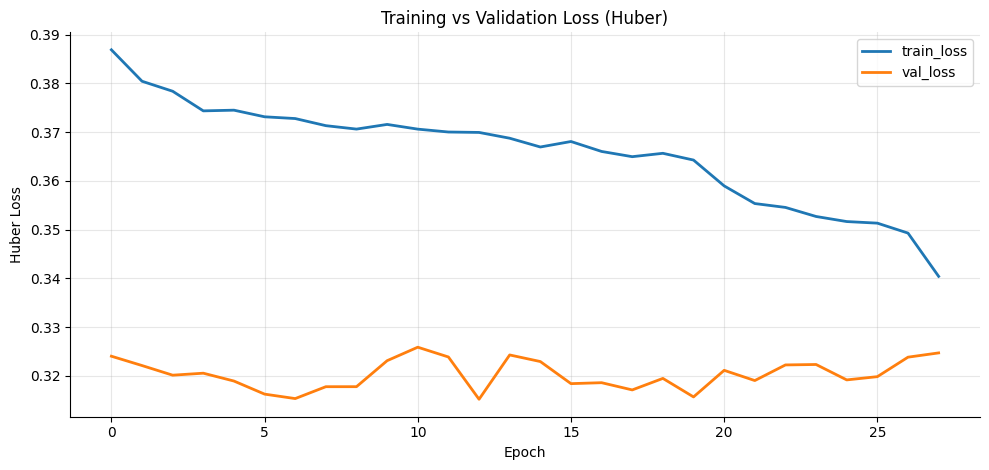

In [29]:
# Convert training history to DataFrame
history_df = pd.DataFrame(history.history)

# Plot training vs validation loss
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(history_df["loss"],     label="train_loss", linewidth=2)
ax.plot(history_df["val_loss"], label="val_loss",   linewidth=2)

ax.set_title("Training vs Validation Loss (Huber)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.grid(True, alpha=0.3)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
# Generate predictions on all splits
y_pred_test_sc = model.predict(X_test_final)

# Inverse-transform back to original return scale
y_pred_test = scaler_y.inverse_transform(y_pred_test_sc)
y_true_test = scaler_y.inverse_transform(y_test_final)

# Evaluation metrics
mae  = metrics.mean_absolute_error(y_true_test, y_pred_test)
rmse = np.sqrt(metrics.mean_squared_error(y_true_test, y_pred_test))
r2   = metrics.r2_score(y_true_test, y_pred_test)
print(f"MAE:  {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²:   {r2:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
MAE:  0.01392
RMSE: 0.01995
R²:   -0.0056


In [31]:
# Generate predictions for all splits
y_pred_train_sc = np.concatenate(
    (np.zeros([lag, 1]), model.predict(X_train_final)), axis=0)

y_pred_valid_sc = np.concatenate(
    (np.zeros([lag, 1]), model.predict(X_valid_final)), axis=0)

y_pred_test_sc = np.concatenate(
    (np.zeros([lag, 1]), model.predict(X_test_final)), axis=0)

# Inverse transform all predictions to original return scale
full_pred_sc = np.concatenate(
    (y_pred_train_sc, y_pred_valid_sc, y_pred_test_sc), axis=0)

df["prediction"] = scaler_y.inverse_transform(full_pred_sc)

174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [32]:
# Compute strategy returns
df["strategy"] = (
    df["return"] * np.sign(df["prediction"].shift(1))
)
display(df.sample(15))

,open,high,low,close,volume,cac40_return,return,lag_open,lag_high,lag_low,...,bb_lower,bb_width,atr,obv,cac40_return_lag,day_of_week,month,quarter,prediction,strategy
date,,,,,,,,,,,,,,,,,,,,,
2006-02-16,50.829946,50.931067,50.290634,50.661411,714580,0.007904,0.000000,50.931067,50.964771,50.459168,...,49.336116,2.237316,0.796391,49709326.0,-0.005492,3,2,1,-0.000951,-0.000000
2010-04-06,65.578832,65.873569,64.768308,65.092514,1139493,0.004886,-0.002935,64.178857,65.320963,63.906229,...,62.846637,2.453824,1.170589,44442199.0,0.015153,1,4,2,-0.000841,0.002935
2012-04-11,96.621840,97.925466,95.548263,97.542046,1134725,0.006244,0.011933,98.002177,98.385597,96.315125,...,95.861944,8.118019,2.130736,56114971.0,-0.030788,2,4,2,0.000784,-0.011933
2007-06-21,58.694146,59.519751,58.694146,59.304680,1706924,-0.010421,0.001171,59.047971,59.658499,59.047971,...,57.932554,3.270825,0.944269,79111859.0,0.003561,3,6,2,-0.001022,-0.001171
2023-01-25,748.658688,754.508332,742.620334,747.526489,282357,-0.000936,-0.003145,745.639492,750.356937,741.676825,...,634.757256,154.817132,15.533132,143397810.0,0.002625,2,1,1,-0.000288,0.003145
2005-12-22,50.998478,51.167012,50.762531,50.998478,626005,-0.000095,0.000661,50.425491,51.032211,50.324369,...,48.469033,3.069572,0.717456,50701901.0,0.010403,3,12,4,-0.000685,-0.000661
2003-04-15,25.553269,26.001570,25.335522,25.457203,1891493,0.016188,0.008883,25.085763,25.482833,24.759143,...,22.281389,5.496738,1.124515,-25854859.0,0.012980,1,4,2,0.000047,0.008883
2006-04-26,57.537621,57.807277,57.032018,57.503918,880284,0.003243,0.004711,57.133147,57.470215,56.897199,...,52.364335,4.219841,0.812033,71898322.0,0.002662,2,4,2,-0.000885,-0.004711
2024-08-27,661.683064,664.101850,646.589805,648.041077,293654,-0.003240,-0.017889,659.361030,663.714845,658.780545,...,590.692022,73.999722,11.490565,141123527.0,0.001759,1,8,3,-0.001356,0.017889


In [33]:
import plotly.graph_objects as go

# Cumulative strategy return
cum_strategy = df["strategy"].cumsum()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=cum_strategy,
        mode="lines",
        name="Strategy",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="Cumulative Strategy Return",
    xaxis_title="Time",
    yaxis_title="Cumulative Return",
    template="plotly_white",
    height=600,
    margin=dict(l=40, r=40, t=70, b=40)
)

fig.show()